## Équation de la chaleur 1D résolution par un PINN

In [21]:
import jax
import jax.numpy as jnp
import functools
import numpy as np
import optax
import matplotlib.pyplot as plt

In [22]:
print(jax.devices())

[CudaDevice(id=0)]


**Domaine et constantes Pyhsique**

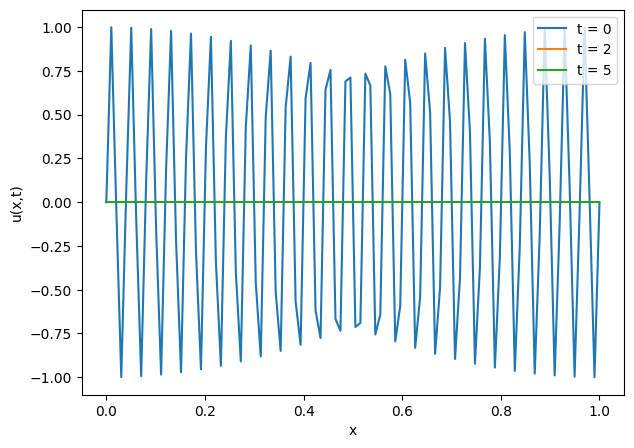

In [ ]:
#Longueur de la barre (m)
L = 1
#Temps total de la simulation (s)
T = 5
#Coefficient de diffusion (m^2/s)
kappa = 1e-2
#Valeur propre
omega = jnp.pi/L
#Conditions aux limites de Dirichlet homogènes
#En x=0 u=0 pour tout t
CL0 = 0
#En x=L u=0 pour tout t
CLL = 0
#Condition initial
#u(x,0) = sin(omega*x)
#Exact solution
def u_exact(x,t):
    return jnp.exp(-kappa*omega**2*t)*jnp.sin(omega*x)
#Plot de la solution
time = [0,2,5]
x = jnp.linspace(0,L,100)
plt.figure(figsize=(7,5))
for t in time:
    plt.plot(x,u_exact(x,t),label=f"t = {t}")
plt.legend(loc="upper right")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.show()

**Initialisation des paramètres**

In [24]:
key = jax.random.key(0) #initialisation de la PRNG
#Taille de l'entré
n_input = 2
#Taille de la sortie
n_output = 1
#nombre de couches cachée
n_layers = [n_input,64,64,64,n_output]

def init_layers(key,n_layers):
    layers = []
    for i in range(len(n_layers)-1):
        key, subkey = jax.random.split(key)
        W = jax.random.normal(subkey,(n_layers[i],n_layers[i+1]))/jnp.sqrt(n_layers[i])
        b = jnp.zeros(n_layers[i+1])
        layers.append({"W" : W,"b" : b})
    return layers, key

key, subkey = jax.random.split(key)
layers, key = init_layers(subkey,n_layers)
#si besoin je peux ajouter kappa comme inconnu par exemple
params = {
    "layers" : layers
}

**Le Forward**

In [25]:
def forward(params,X):
    n = len(params["layers"])
    Z = X
    for i in range(n-1):
        Z = jax.nn.tanh(Z @ params["layers"][i]["W"] + params["layers"][i]["b"])
    Z = Z @ params["layers"][-1]["W"] + params["layers"][-1]["b"]
    return Z

**La loss function**

In [26]:
#Il faut normaliser les valeurs du réseau
def loss_fn(params, x, t, omega, kappa, N):

    def u(x_val, t_val):
        return forward(params, jnp.array([x_val, t_val])).squeeze()
    
    def pde_residual(x_val, t_val):
        u_t = 2*jax.grad(u, argnums=1)(x_val, t_val)/T
        u_xx = 4*jax.grad(jax.grad(u))(x_val, t_val)/L**2
        return u_t - kappa * u_xx
    
    vmap_u = jax.vmap(u, in_axes=(0,0))
    vmap_pde_residual = jax.vmap(pde_residual, in_axes=(0,0))

    residuals = vmap_pde_residual(x, t)
    pde_loss = jnp.mean(residuals**2)

    zeroscond = -jnp.ones(N)
    x1 = jnp.ones(N)
    bc_loss = jnp.mean((vmap_u(zeroscond, t) - CL0)**2) + jnp.mean((vmap_u(x1, t) - CLL)**2)
    ic_loss = jnp.mean((vmap_u(x,zeroscond)-jnp.sin(omega*(x+1)*L/2))**2)

    total_loss = pde_loss + bc_loss + ic_loss
    
    return total_loss, (pde_loss, bc_loss, ic_loss)

**Le training**

In [27]:
lr = 3e-4

optimizer = optax.adam(lr)

@functools.partial(jax.jit, static_argnames=('N',))
def train_step(params,opt_state,N,key):
    key, subkey1, subkey2 = jax.random.split(key, 3)
    x = jax.random.uniform(subkey1, (N,), minval=-1, maxval=1)
    t = jax.random.uniform(subkey2, (N,), minval=-1, maxval=1)
    (loss, _), grads = jax.value_and_grad(loss_fn, has_aux=True)(params, x, t, omega, kappa, N)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss, key

@functools.partial(jax.jit, static_argnames=('Nmc',))
def eval_step(params, x, t, Nmc):
    return loss_fn(params, x, t, omega, kappa, Nmc)

def train(params, Nmc, num_steps, eval_interval, key):
    opt_state = optimizer.init(params)
    train_loss = []
    rel_err = []
    def u(params, x_val, t_val):
        return forward(params, jnp.array([x_val, t_val])).squeeze()
    vmap_u = jax.vmap(u, in_axes=(None, 0, 0))
    i = 0
    for step in range(num_steps):
        params, opt_state, loss, key = train_step(params, opt_state, Nmc, key)
        if step % eval_interval == 0:
            key, subkey1, subkey2 = jax.random.split(key, 3)
            x = jax.random.uniform(subkey1, (Nmc,), minval=-1, maxval=1)
            t = jax.random.uniform(subkey2, (Nmc,), minval=-1, maxval=1)
            rel_err.append(jnp.sqrt(jnp.mean((vmap_u(params,x,t) - u_exact((x+1)*L/2,(t+1)*T/2))**2)/jnp.mean((u_exact((x+1)*L/2,(t+1)*T/2))**2)))
            _ , (pde_val, bc_val, ic_val) = eval_step(params, x, t, Nmc)
            train_loss.append((pde_val, bc_val, ic_val))
            print(f"step {step} | pde loss {pde_val:.2e} | bc loss {bc_val:.2e} | ic loss {ic_val:.2e} | L2 relative error {rel_err[i]*100:.2f} %")
            i+=1
    return params, key, train_loss, rel_err


**La phase d'entrainement**

In [28]:
num_steps = 50000
eval_interval = num_steps//20
Nmc = 5000

key, subkey = jax.random.split(key)
best_params, key, train_loss, test_loss = train(params, Nmc, num_steps, eval_interval, subkey)

step 0 | pde loss 6.87e-03 | bc loss 4.02e-02 | ic loss 5.10e-01 | L2 relative error 219.39 %
step 2500 | pde loss 7.05e-05 | bc loss 1.56e-04 | ic loss 4.91e-01 | L2 relative error 103.01 %
step 5000 | pde loss 9.43e-05 | bc loss 4.53e-04 | ic loss 5.03e-01 | L2 relative error 103.49 %
step 7500 | pde loss 7.23e-05 | bc loss 2.23e-04 | ic loss 4.99e-01 | L2 relative error 101.78 %
step 10000 | pde loss 8.46e-05 | bc loss 2.64e-04 | ic loss 5.01e-01 | L2 relative error 102.11 %
step 12500 | pde loss 9.00e-05 | bc loss 2.88e-04 | ic loss 4.92e-01 | L2 relative error 102.44 %
step 15000 | pde loss 1.00e-04 | bc loss 2.89e-04 | ic loss 5.02e-01 | L2 relative error 102.97 %
step 17500 | pde loss 7.96e-05 | bc loss 2.25e-04 | ic loss 5.00e-01 | L2 relative error 101.20 %
step 20000 | pde loss 9.12e-05 | bc loss 3.64e-04 | ic loss 4.99e-01 | L2 relative error 99.72 %
step 22500 | pde loss 1.37e-04 | bc loss 3.01e-04 | ic loss 5.00e-01 | L2 relative error 100.47 %
step 25000 | pde loss 1.87e-

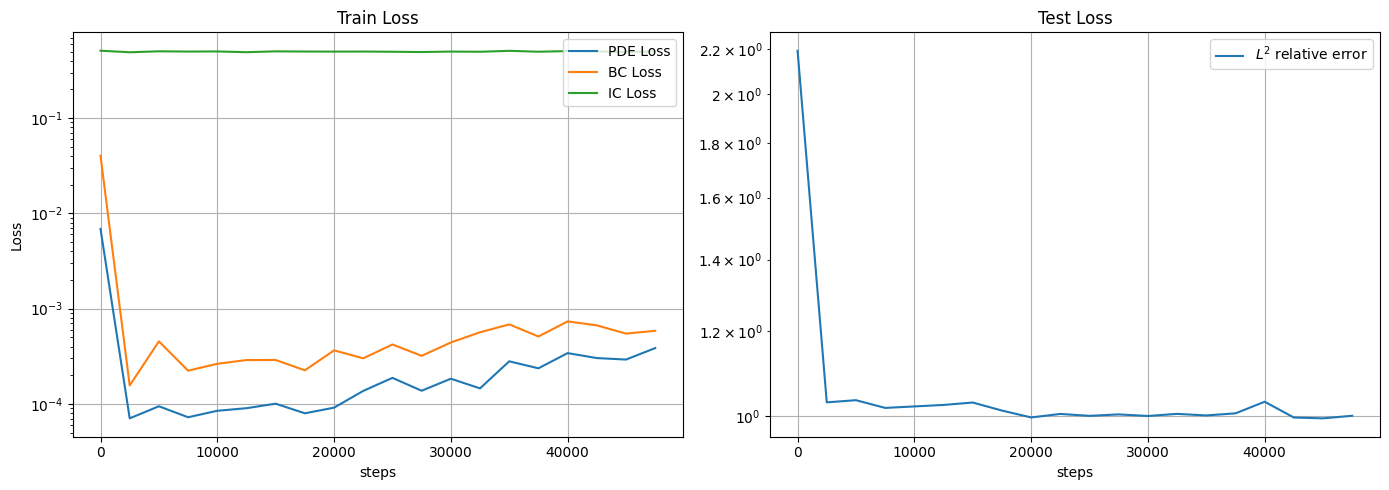

In [ ]:
#Print des métriques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.semilogy(eval_interval*np.arange(num_steps//eval_interval), np.array(train_loss)[:,0], label="PDE Loss")
ax1.semilogy(eval_interval*np.arange(num_steps//eval_interval), np.array(train_loss)[:,1], label="BC Loss")
ax1.semilogy(eval_interval*np.arange(num_steps//eval_interval), np.array(train_loss)[:,2], label="IC Loss")

ax2.semilogy(eval_interval*np.arange(num_steps//eval_interval), test_loss, label="$L^2$ relative error")

ax1.set_title("Train Loss")
ax1.set_xlabel("steps")
ax1.set_ylabel("Loss")
ax1.legend(loc="upper right")
ax1.grid(True)

ax2.set_title("Test Loss")
ax2.set_xlabel("steps")
ax2.legend(loc="upper right")
ax2.grid(True)

plt.tight_layout()
plt.savefig('fig/Heat_eq_1D_Loss_base_f_50.pdf')
plt.show()

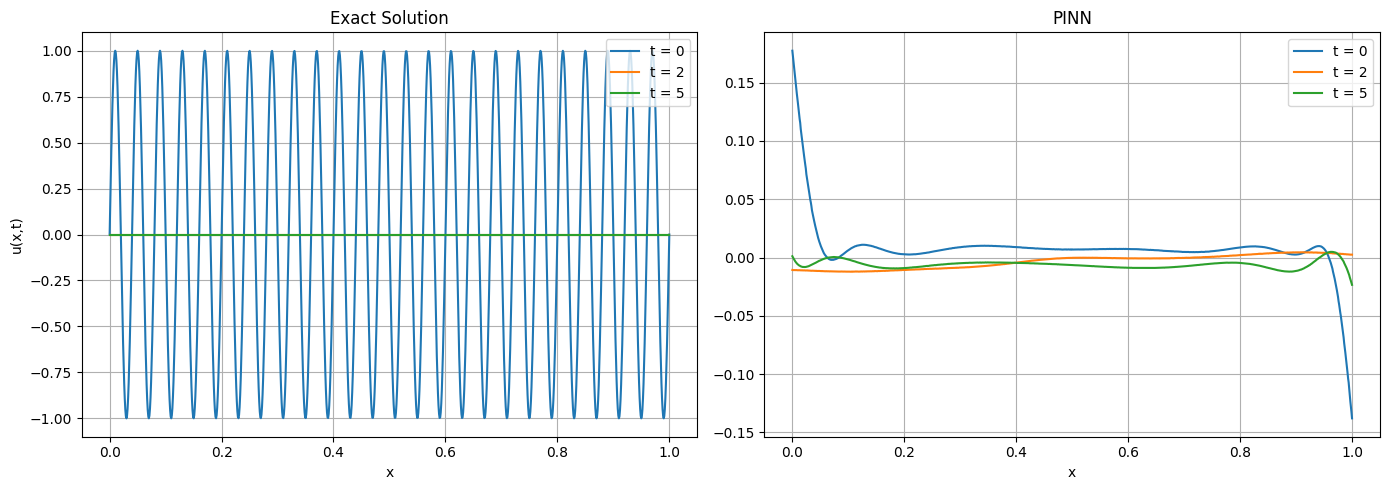

In [ ]:
#Plot de la solution et de l'approximation du PINN
def u_pinn(x, t):
    return forward(best_params, jnp.array([x, t])).squeeze()

time = [0,2,5]
x = jnp.linspace(0,L,1000)

vmap_u_pinn = jax.vmap(u_pinn, in_axes=(0, None))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for t in time:
    ax1.plot(x, u_exact(x,t), label=f"t = {t}")
    ax2.plot(x, vmap_u_pinn(2*x/L-1,2*t/T-1), label=f"t = {t}")

ax1.set_title("Exact Solution")
ax1.set_xlabel("x")
ax1.set_ylabel("u(x,t)")
ax1.legend(loc="upper right")
ax1.grid(True)

ax2.set_title("PINN")
ax2.set_xlabel("x")
ax2.legend(loc="upper right")
ax2.grid(True)

plt.tight_layout()
plt.savefig('fig/Heat_eq_1D_test_PINN_base_f_50.pdf')
plt.show()